# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Haikal Javier Rachman
- Email: haikaljavierrachman@gmail.com
- Id Dicoding:javierrachman

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import joblib

### Menyiapkan data yang akan diguankan

In [2]:
# Membaca dataset dengan pemisah semicolon sesuai file data.csv
df = pd.read_csv('data.csv', sep=';')

## Data Understanding

In [3]:
# Cek informasi dasar
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Cek duplikasi data
print("Jumlah duplikasi data : ", df.duplicated().sum())

Jumlah duplikasi data :  0


In [5]:
# Cek data null
print(df.isnull().sum())

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [6]:
df.describe(include="all")

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


Insight:
Tidak ada data duplikat dan data null

## Data Preparation / Preprocessing

In [7]:
# transform value dataset menjadi kategorik
# 2. Definisikan Mapping Lengkap berdasarkan Penjelasan Data.md
# Menambahkan mapping Course agar lebih spesifik di Dashboard
course_mapping = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Design and Graphic Design',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}

other_mappings = {
    'Marital_status': {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'},
    'Daytime_evening_attendance': {1: 'Daytime', 0: 'Evening'},
    'Displaced': {1: 'Yes', 0: 'No'},
    'Educational_special_needs': {1: 'Yes', 0: 'No'},
    'Debtor': {1: 'Yes', 0: 'No'},
    'Tuition_fees_up_to_date': {1: 'Yes', 0: 'No'},
    'Gender': {1: 'Male', 0: 'Female'},
    'Scholarship_holder': {1: 'Yes', 0: 'No'},
    'International': {1: 'Yes', 0: 'No'}
}

# 3. Buat Salinan untuk Dataset Fix
df_kategorik = df.copy()

# 4. Terapkan Mapping
df_kategorik['Course'] = df_kategorik['Course'].map(course_mapping)

for col, mapping in other_mappings.items():
    if col in df_kategorik.columns:
        df_kategorik[col] = df_kategorik[col].map(mapping)

df_kategorik.to_csv('data_kategorik.csv', index=False)

Transform data numerik menjadi kategorik

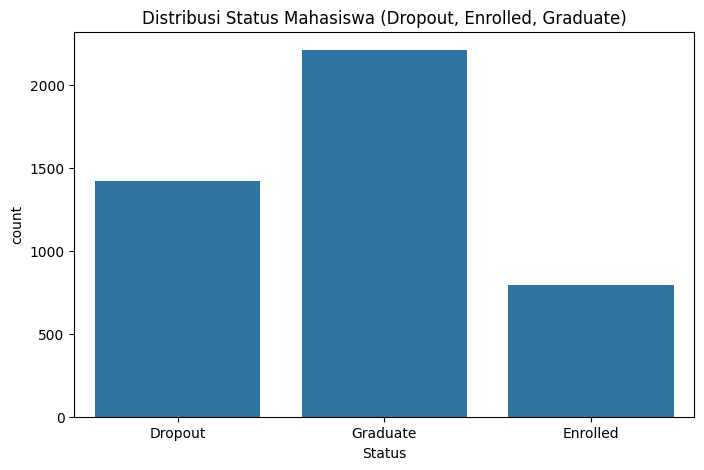

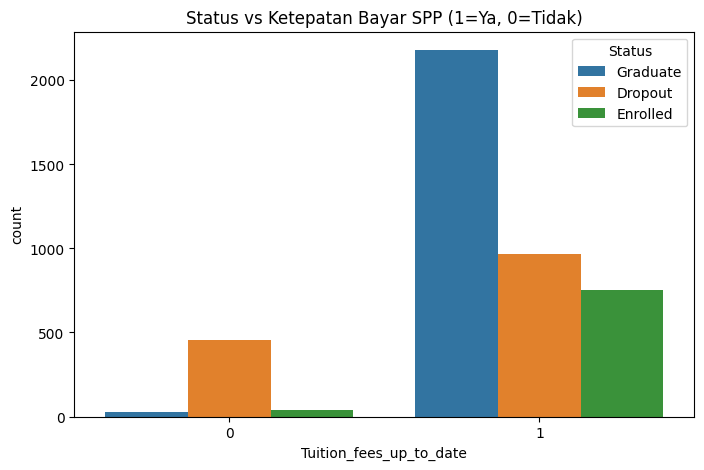

In [8]:
# Visualisasi distribusi Target (Status)
plt.figure(figsize=(8, 5))
sns.countplot(x='Status', data=df)
plt.title('Distribusi Status Mahasiswa (Dropout, Enrolled, Graduate)')
plt.show()

# Hubungan antara Pembayaran SPP (Tuition_fees_up_to_date) dengan Dropout
plt.figure(figsize=(8, 5))
sns.countplot(x='Tuition_fees_up_to_date', hue='Status', data=df)
plt.title('Status vs Ketepatan Bayar SPP (1=Ya, 0=Tidak)')
plt.show()

Analisis Persentase Status Berdasarkan Finansial:
Status                      Dropout  Enrolled  Graduate
Debtor Scholarship_holder                              
0      0                   0.346180  0.199931  0.453889
       1                   0.101478  0.121182  0.777340
1      0                   0.670644  0.198091  0.131265
       1                   0.369048  0.083333  0.547619


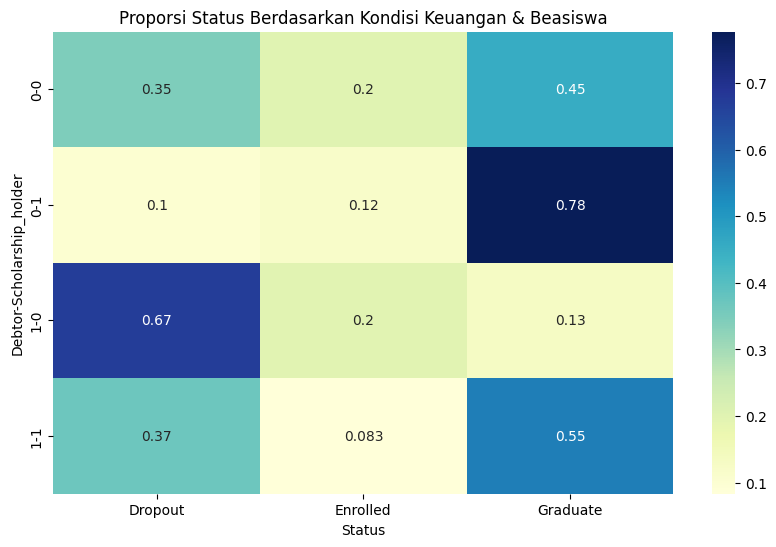

In [9]:
# Pivot table untuk melihat hubungan Debtor, Scholarship, dan Status
financial_analysis = df.groupby(['Debtor', 'Scholarship_holder'])['Status'].value_counts(normalize=True).unstack()
print("Analisis Persentase Status Berdasarkan Finansial:")
print(financial_analysis)

# Visualisasi dengan Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(financial_analysis, annot=True, cmap='YlGnBu')
plt.title('Proporsi Status Berdasarkan Kondisi Keuangan & Beasiswa')
plt.show()

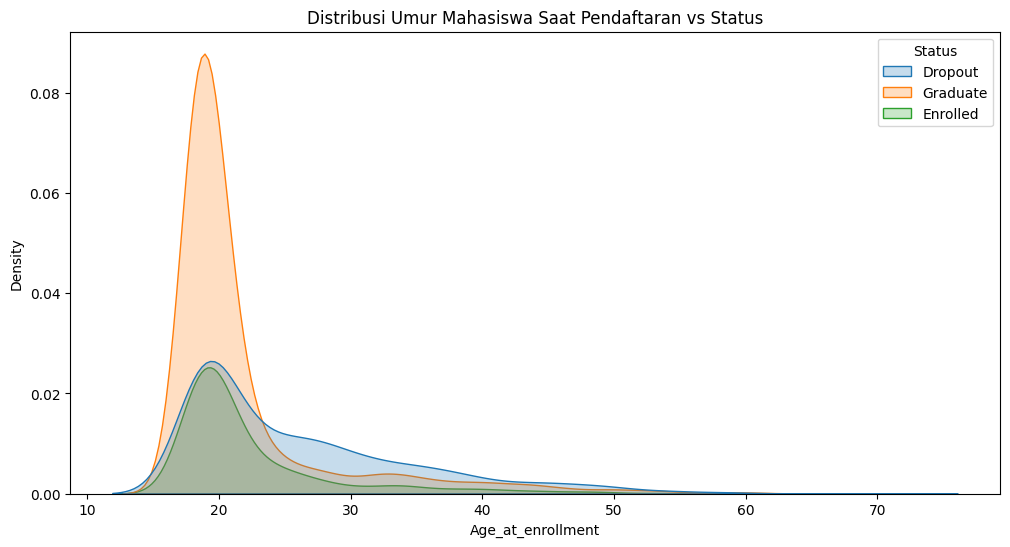

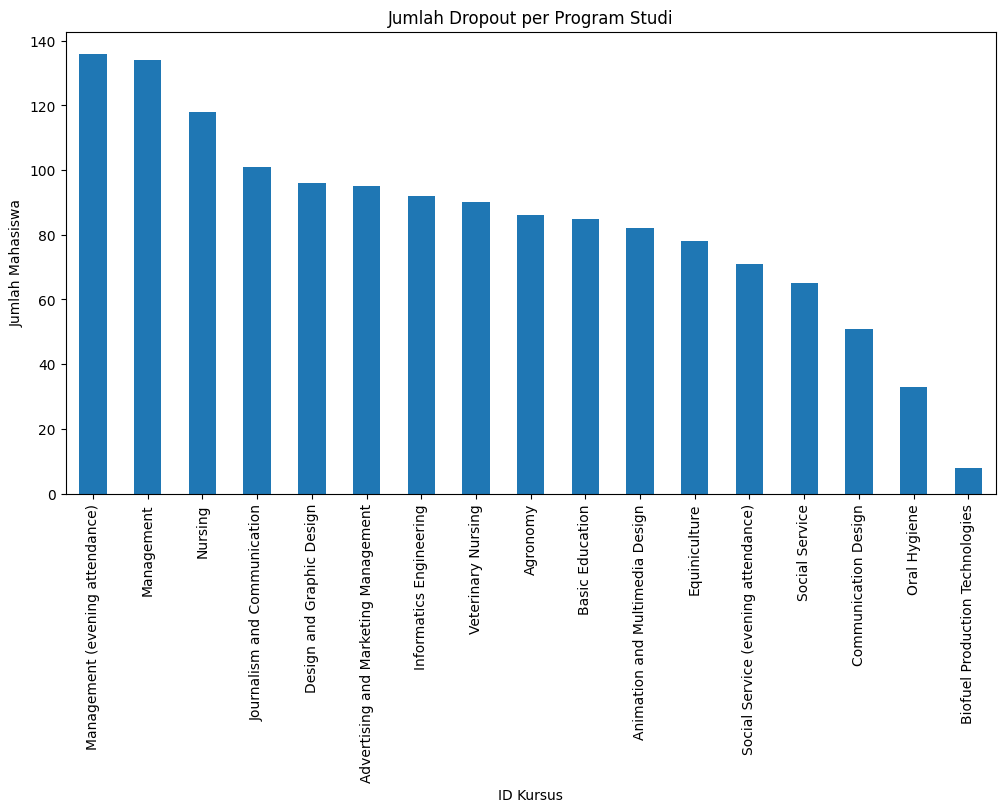

In [10]:
# Distribusi umur berdasarkan Status
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Age_at_enrollment', hue='Status', fill=True)
plt.title('Distribusi Umur Mahasiswa Saat Pendaftaran vs Status')
plt.show()

# Hubungan Kursus (Course) dengan Dropout
course_dropout = df_kategorik[df_kategorik['Status'] == 'Dropout']['Course'].value_counts()
plt.figure(figsize=(12, 6))
course_dropout.plot(kind='bar')
plt.title('Jumlah Dropout per Program Studi')
plt.xlabel('ID Kursus')
plt.ylabel('Jumlah Mahasiswa')
plt.show()


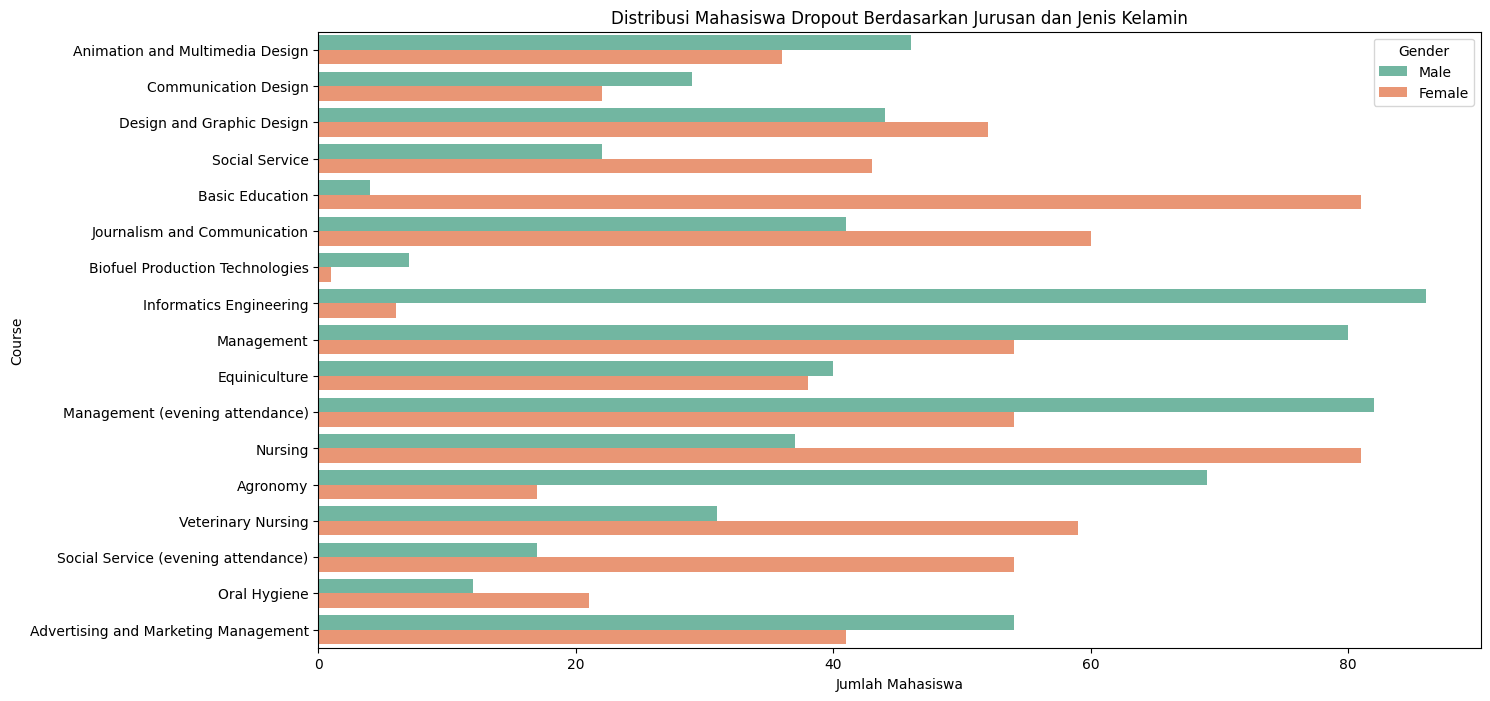

In [11]:
plt.figure(figsize=(15, 8))
# Melihat perbandingan dropout berdasarkan Gender di setiap Course
sns.countplot(data=df_kategorik[df_kategorik['Status'] == 'Dropout'],
              y='Course',
              hue='Gender',
              palette='Set2')
plt.title('Distribusi Mahasiswa Dropout Berdasarkan Jurusan dan Jenis Kelamin')
plt.xlabel('Jumlah Mahasiswa')
plt.show()

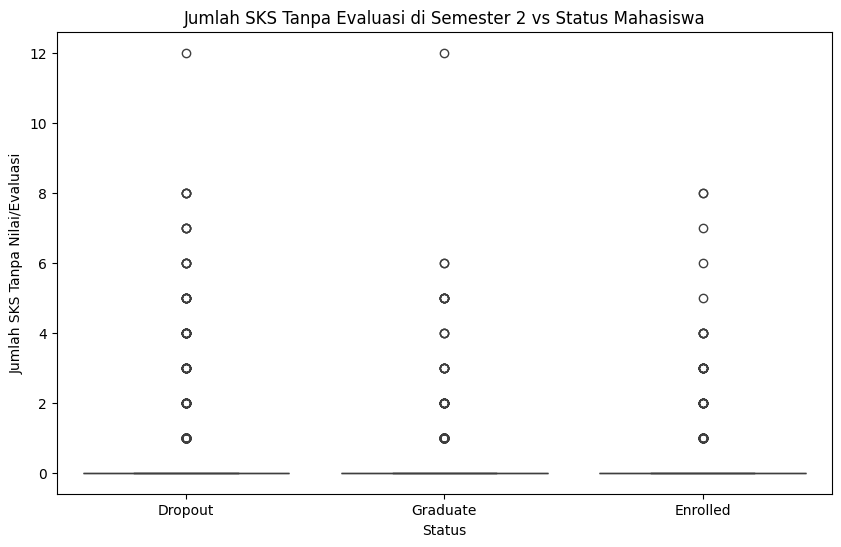

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Status',
            y='Curricular_units_2nd_sem_without_evaluations',
            data=df_kategorik)
plt.title('Jumlah SKS Tanpa Evaluasi di Semester 2 vs Status Mahasiswa')
plt.ylabel('Jumlah SKS Tanpa Nilai/Evaluasi')
plt.show()

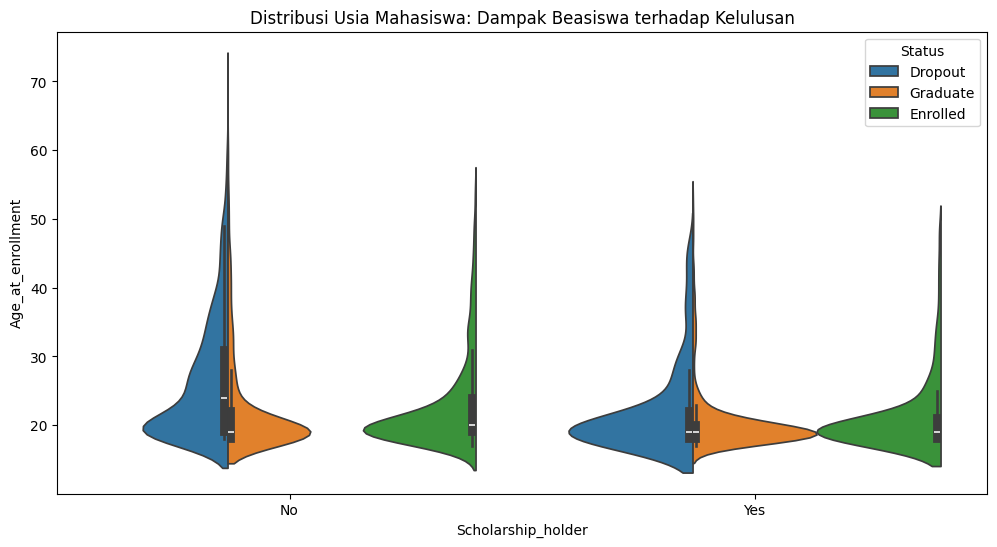

In [13]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='Scholarship_holder',
               y='Age_at_enrollment',
               hue='Status',
               data=df_kategorik,
               split=True)
plt.title('Distribusi Usia Mahasiswa: Dampak Beasiswa terhadap Kelulusan')
plt.show()

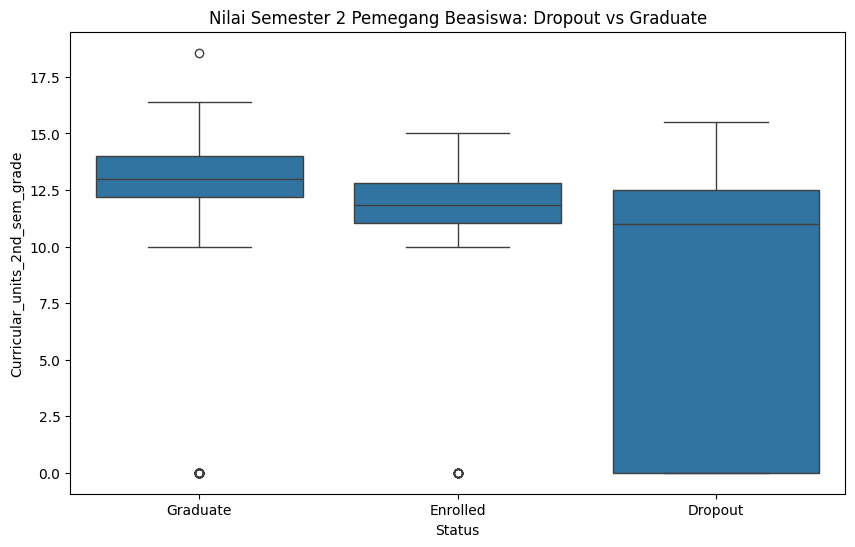

In [14]:
# Filter hanya pemegang beasiswa
df_scholarship = df_kategorik[df_kategorik['Scholarship_holder'] == 'Yes']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_scholarship, x='Status', y='Curricular_units_2nd_sem_grade')
plt.title('Nilai Semester 2 Pemegang Beasiswa: Dropout vs Graduate')
plt.show()

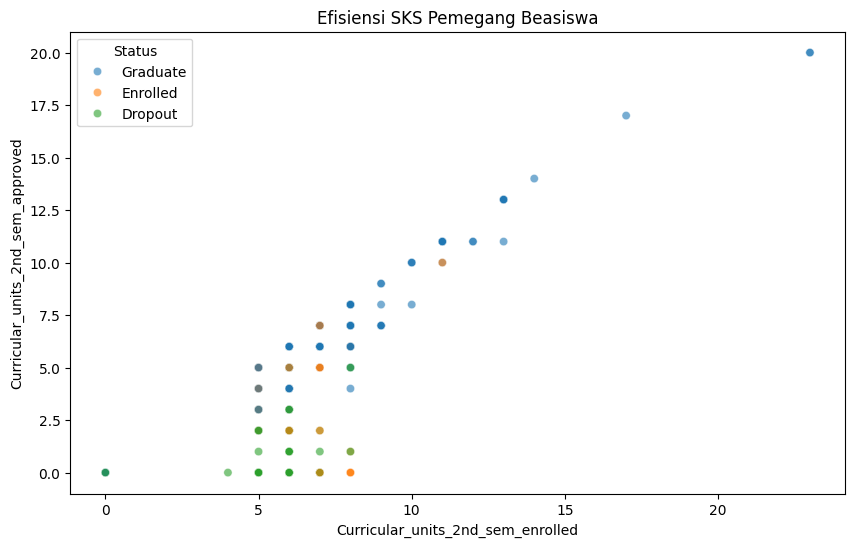

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scholarship,
                x='Curricular_units_2nd_sem_enrolled',
                y='Curricular_units_2nd_sem_approved',
                hue='Status', alpha=0.6)
plt.title('Efisiensi SKS Pemegang Beasiswa')
plt.show()

<Figure size 800x500 with 0 Axes>

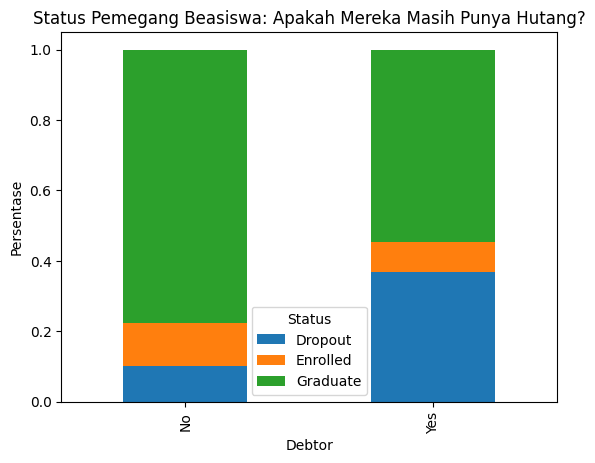

In [16]:
# Cross-tab antara Debtor dan Status khusus pemegang beasiswa
debtor_scholarship = df_scholarship.groupby('Debtor')['Status'].value_counts(normalize=True).unstack()

plt.figure(figsize=(8, 5))
debt_plot = debtor_scholarship.plot(kind='bar', stacked=True)
plt.title('Status Pemegang Beasiswa: Apakah Mereka Masih Punya Hutang?')
plt.ylabel('Persentase')
plt.show()

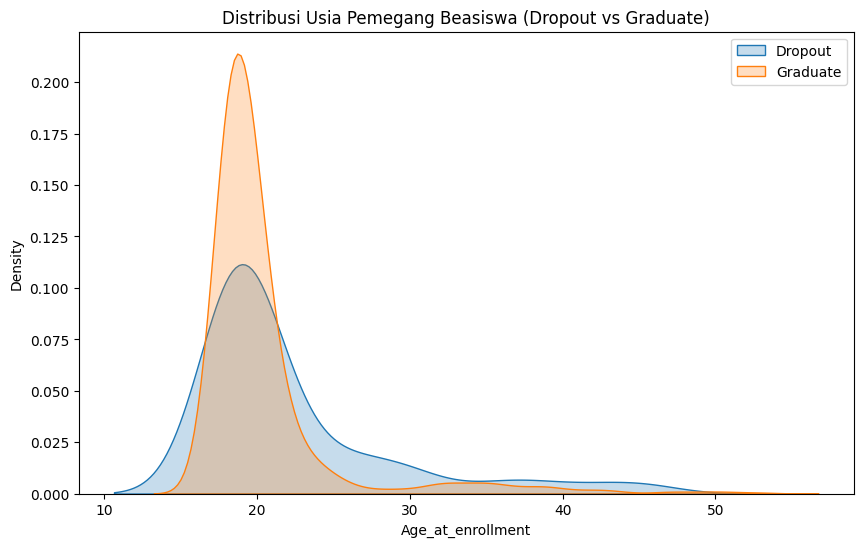

In [17]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_scholarship[df_scholarship['Status'] == 'Dropout'], x='Age_at_enrollment', label='Dropout', fill=True)
sns.kdeplot(data=df_scholarship[df_scholarship['Status'] == 'Graduate'], x='Age_at_enrollment', label='Graduate', fill=True)
plt.title('Distribusi Usia Pemegang Beasiswa (Dropout vs Graduate)')
plt.legend()
plt.show()

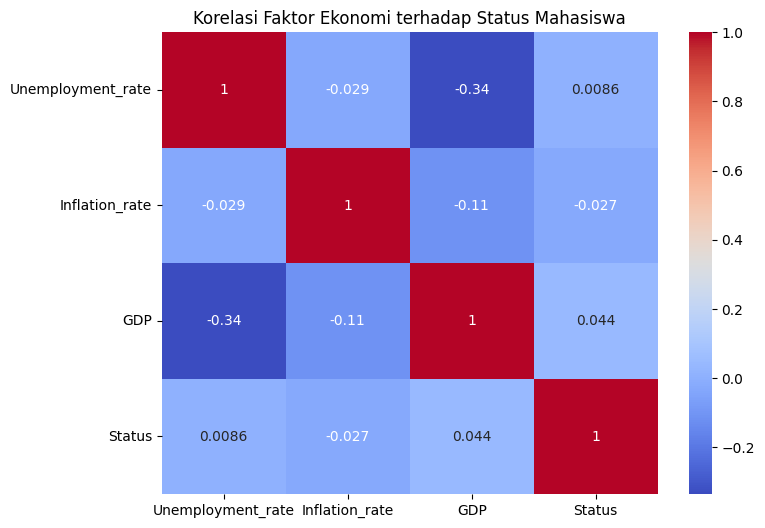

In [18]:
macro_features = ['Unemployment_rate', 'Inflation_rate', 'GDP', 'Status']
# (Pastikan Anda sudah mengubah Status ke numerik sebelumnya)
# Membuat instance LabelEncoder
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

plt.figure(figsize=(8, 6))
sns.heatmap(df[macro_features].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Faktor Ekonomi terhadap Status Mahasiswa')
plt.show()

## Modeling

In [19]:
df['SKS_Stability'] = df['Curricular_units_2nd_sem_approved'] - df['Curricular_units_1st_sem_approved']
df['Grade_Improvement'] = df['Curricular_units_2nd_sem_grade'] - df['Curricular_units_1st_sem_grade']

# 3. Memisahkan Fitur dan Target
X = df.drop('Status', axis=1)
y = df['Status']

# 4. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Handling Imbalance dengan SMOTE
# Ini penting karena jumlah 'Graduate' biasanya jauh lebih banyak dari 'Dropout'
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Jumlah data setelah SMOTE:", X_train_res.shape)

Jumlah data setelah SMOTE: (5301, 38)


In [20]:
# Inisialisasi Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training
rf_model.fit(X_train_res, y_train_res)

# Simpan model untuk digunakan di Streamlit (Kriteria 4)
joblib.dump(rf_model, 'model_student_performance.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [21]:
# Select Hyper Tuning
# Split ulang dengan fitur baru
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# --- STEP 2: Hyperparameter Tuning ---
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

# Mencari kombinasi terbaik
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

# Model Terbaik
best_rf = grid_search.best_estimator_

print("Parameter Terbaik:", grid_search.best_params_)

Parameter Terbaik: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## Evaluation

Akurasi Model: 75.37%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.72      0.77       284
    Enrolled       0.47      0.53      0.50       159
    Graduate       0.82      0.86      0.84       442

    accuracy                           0.75       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.75      0.76       885



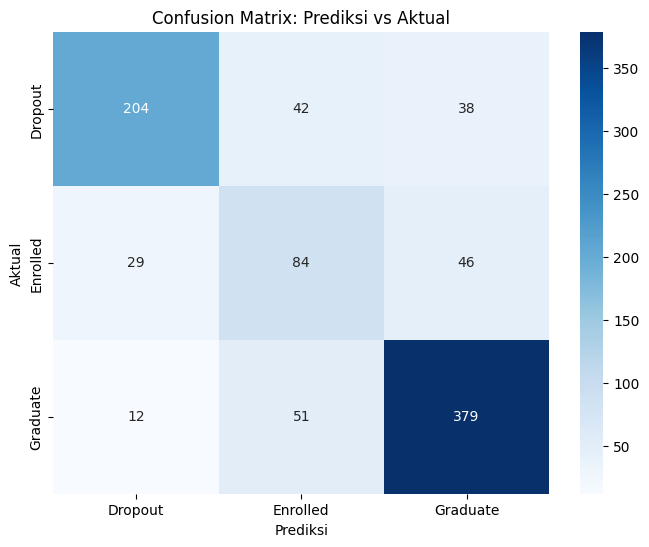

In [22]:
# Prediksi data test
y_pred = rf_model.predict(X_test)

# 1. Accuracy Score
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 2. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Prediksi vs Aktual')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [23]:
y_pred_new = best_rf.predict(X_test)
new_accuracy = accuracy_score(y_test, y_pred_new)

print(f"Akurasi Model Baru: {new_accuracy * 100:.2f}%")
print("\nNew Classification Report:")
print(classification_report(y_test, y_pred_new, target_names=le.classes_))

# Simpan model final
joblib.dump(best_rf, 'model_student_final.pkl')

Akurasi Model Baru: 76.05%

New Classification Report:
              precision    recall  f1-score   support

     Dropout       0.85      0.71      0.78       284
    Enrolled       0.48      0.57      0.52       159
    Graduate       0.83      0.86      0.84       442

    accuracy                           0.76       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.76      0.76       885



['model_student_final.pkl']